# Min-Max Normalisation

## 🧩 Question:

Implement the **Minimax algorithm** for a two-player game.

- Represent the game as a decision tree
- Apply recursive evaluation of nodes
- Determine the optimal move for the maximizing player


User Inputs:
Depth = 2
Branching Factor = 3

Leaf Node Utilities: [9, -4, -8, -1, -7, 7, 4, 0, -4]
Optimal Value (Min-max): -4


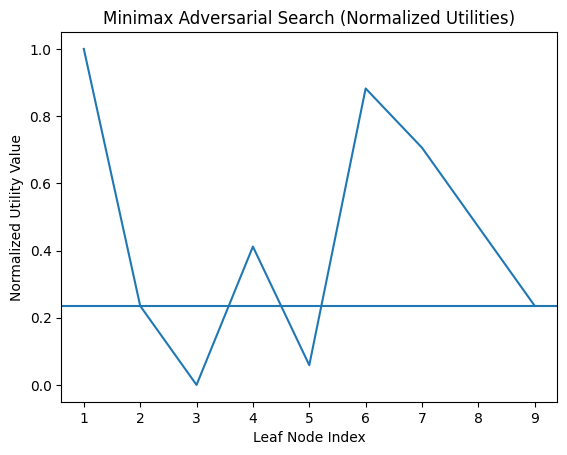

In [12]:
# Adversarial Search using Minimax Algorithm
# Demonstration with user-defined depth and branching factor
# Uses normalization for evaluation visualization

import random
import matplotlib.pyplot as plt
import numpy as np

# ---------------- User Inputs (Example) ----------------
depth = int(input("Enter Depth of Game Tree:"))                 # Depth of game tree
branching_factor = int(input("Enter no. of children per node:"))      # Number of children per node

print("User Inputs:")
print("Depth =", depth)
print("Branching Factor =", branching_factor)

# Generate leaf node utilities randomly
def generate_leaf_values(depth, branching_factor):
    total_leaves = branching_factor ** depth
    return [random.randint(-10, 10) for _ in range(total_leaves)]

# Minimax Algorithm
def minimax(values, depth, maximizing_player, branching_factor):
    if depth == 0:
        return values.pop(0)
    
    if maximizing_player:
        best = -float('inf')
        for _ in range(branching_factor):
            val = minimax(values, depth - 1, False, branching_factor)
            best = max(best, val)
        return best
    else:
        best = float('inf')
        for _ in range(branching_factor):
            val = minimax(values, depth - 1, True, branching_factor)
            best = min(best, val)
        return best

# Normalization Function
def normalize(values):
    min_val = min(values)
    max_val = max(values)
    return [(v - min_val) / (max_val - min_val) if max_val != min_val else 0 for v in values]

# Generate game tree leaf values
leaf_values = generate_leaf_values(depth, branching_factor)
leaf_copy = leaf_values.copy()

# Apply Minimax
optimal_value = minimax(leaf_copy, depth, True, branching_factor)

print("\nLeaf Node Utilities:", leaf_values)
print("Optimal Value (Min-max):", optimal_value)

# Normalize leaf values for visualization
normalized_leaf = normalize(leaf_values)

# ---------------- Plot ----------------
plt.figure()
plt.plot(range(1, len(normalized_leaf) + 1), normalized_leaf)
plt.axhline(y=normalize([optimal_value] + leaf_values)[0])
plt.title("Minimax Adversarial Search (Normalized Utilities)")
plt.xlabel("Leaf Node Index")
plt.ylabel("Normalized Utility Value")
plt.show()
